In [1]:
import slmcontrol
import numpy as np
import matplotlib.pyplot as plt
from common.utils import generate_amplitude_and_phase_hologram
from cameras.Ximea import XimeaCamera

In [2]:
slm = slmcontrol.SLMDisplay(host="localhost")
Nx = slm.width
Ny = slm.height
_xs = np.arange(Nx // 2) - Nx // 4
_ys = np.arange(Ny) - Ny // 2
xs, ys = np.meshgrid(_xs, _ys)

In [3]:
mode = slmcontrol.lg(xs, ys, w=20, l=1)
holo = generate_amplitude_and_phase_hologram(mode, -np.angle(mode), 192, -3, 19)
slm.updateArray(np.zeros_like(holo))

In [17]:
camera = XimeaCamera()
N = 1000
mean_bg = np.zeros_like(camera.capture() / N)

for n in range(N):
    mean_bg += camera.capture() / N

camera.close()

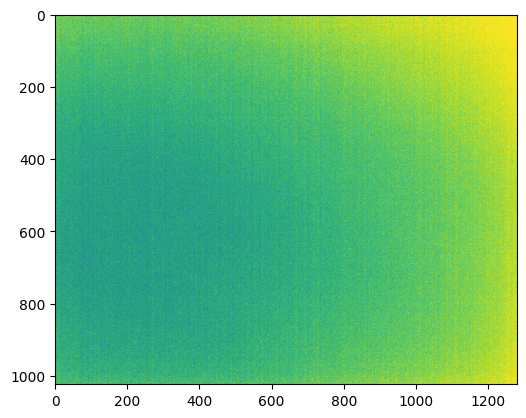

In [19]:
plt.imshow(mean_bg, vmin=0, vmax=4)

(array([0.00000e+00, 2.68870e+04, 7.08606e+05, 5.28537e+05, 4.63490e+04,
        2.81000e+02, 3.60000e+01, 1.30000e+01, 3.00000e+00, 5.00000e+00,
        0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        1.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19.]),
 <BarContainer object of 19 artists>)

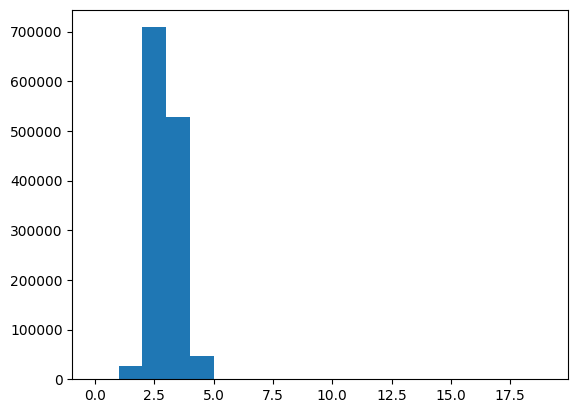

In [9]:
plt.hist(mean_bg.flatten(), bins=range(20))